# Image Classification with CNN on CIFAR-10

This notebook trains a **Convolutional Neural Network (CNN)** to classify small images into **10 categories** using the famous **CIFAR-10 dataset**.

---

###What does this notebook do?
1. Loads the CIFAR-10 dataset (50,000 training + 10,000 test images)
2. Normalizes pixel values for better training stability
3. Builds a CNN model from scratch
4. Compiles the model with an optimizer and loss function
5. Trains the model for 10 epochs
6. Evaluates model accuracy on test data
7. Plots training vs. validation accuracy

---

### CIFAR-10 Classes
The dataset has **10 categories**: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

Each image is **32×32 pixels** with **3 color channels** (RGB).

---

## Step 1 — Import Libraries

We import the tools we need:
- **TensorFlow / Keras** — for building and training the neural network
- `datasets` — provides built-in datasets like CIFAR-10 (auto-downloaded)
- `layers` — building blocks of the neural network (Conv2D, Dense, etc.)
- `models` — for constructing the model architecture
- **Matplotlib** — for plotting the training accuracy curve


In [1]:
# Import necessary libraries
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

## Step 2 — Load and Preprocess the CIFAR-10 Dataset

Keras includes CIFAR-10 as a built-in dataset, so no manual downloading is needed.

After loading:
- `x_train` / `x_test` — the image arrays (shape: `[num_images, 32, 32, 3]`)
- `y_train` / `y_test` — the class labels (integers 0–9)

**Normalization** (`/ 255.0`) scales pixel values from `[0, 255]` down to `[0.0, 1.0]`.
This prevents large number values from destabilizing training and speeds up convergence.

We also define the **10 class names** so we can interpret predictions later.


In [2]:
# Load CIFAR-10 dataset
print("Loading CIFAR-10 dataset...")

# x_train/x_test: image arrays of shape (num_images, 32, 32, 3)
# y_train/y_test: integer class labels 0-9
(x_train, y_train), (x_test, y_test) = datasets.cifar10.load_data()

# Normalize pixel values (0–255 → 0–1) for stable and faster training
x_train = x_train / 255.0
x_test  = x_test  / 255.0

# Human-readable names for each of the 10 output classes
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("Dataset loaded successfully")

Loading CIFAR-10 dataset...
Dataset loaded successfully


## Step 3 — Build the CNN Model

We build a **Sequential CNN** — a stack of layers where data flows top to bottom.

### Architecture Overview

```
Input (32×32×3)
   ↓
Conv2D(32 filters, 3×3) → MaxPool(2×2)    ← Detect basic edges/textures
   ↓
Conv2D(64 filters, 3×3) → MaxPool(2×2)    ← Detect shapes/patterns
   ↓
Conv2D(64 filters, 3×3)                    ← Detect high-level features
   ↓
Flatten
   ↓
Dense(128, ReLU)                            ← Fully connected reasoning
   ↓
Dense(10, Softmax)                          ← Output: probability for each class
```

**Conv2D** — Scans the image with small filters to detect visual features

**MaxPooling2D** — Downsamples the feature map, keeping the most prominent features and reducing computation

**Flatten** — Converts the 3D feature maps into a 1D vector before the Dense layers

**Dense(128)** — A fully connected layer that combines the learned features to make decisions

**Dense(10, Softmax)** — Outputs 10 probabilities (one per class); the highest one is the prediction


In [3]:
# Build a Convolutional Neural Network (CNN)

model = models.Sequential()

# Block 1: First convolution + pooling layer
# 32 filters detect basic features (edges, colors); MaxPool reduces size from 32x32 to 16x16
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

# Block 2: Second convolution + pooling layer
# 64 filters detect more complex patterns; MaxPool reduces size further to 7x7
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Block 3: Third convolution layer (no pooling here)
# 64 filters extract high-level features from the compressed representation
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Flatten: Convert 3D feature maps (e.g., 3x3x64) into a 1D vector (576 values)
model.add(layers.Flatten())

# Fully connected layer: Combines all features to reason about the class
model.add(layers.Dense(128, activation='relu'))

# Output layer: 10 neurons, one per class; softmax converts scores to probabilities
model.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Step 4 — Compile the Model

Before training, we configure how the model learns:

- **Optimizer: `adam`** — Automatically adapts the learning rate; a reliable default for most CNNs
- **Loss: `sparse_categorical_crossentropy`** — Standard loss for multi-class classification when labels are integers (0–9 here); "sparse" means we don't need one-hot encoding
- **Metrics: `accuracy`** — Tracks the percentage of correct predictions during training


In [4]:
# Compile the model (define optimizer, loss, and metrics)

model.compile(
    optimizer='adam',                       # Adaptive learning rate optimizer
    loss='sparse_categorical_crossentropy', # Loss for integer class labels (0-9)
    metrics=['accuracy']                    # Track % of correct predictions
)

## Step 5 — Train the Model

Now we train the CNN on the 50,000 training images.

- **`x_train, y_train`** — The images and their correct labels used for learning
- **`epochs=10`** — The model will go through the entire training set 10 times
- **`validation_data=(x_test, y_test)`** — After each epoch, the model is evaluated on the test set (not used for training) to monitor for overfitting

> **What to watch for:** If training accuracy keeps rising but validation accuracy stops improving (or drops), the model may be overfitting — memorizing training data instead of generalizing.


In [5]:
# Train the CNN model

print("Training started...")

history = model.fit(
    x_train, y_train,               # Training images and their correct labels
    epochs=10,                       # Number of full passes through the training data
    validation_data=(x_test, y_test) # Monitor performance on unseen test data each epoch
)

Training started...
Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 51ms/step - accuracy: 0.4467 - loss: 1.5151 - val_accuracy: 0.5603 - val_loss: 1.2389
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 79s 51ms/step - accuracy: 0.5939 - loss: 1.1484 - val_accuracy: 0.6248 - val_loss: 1.0569
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 50ms/step - accuracy: 0.6495 - loss: 0.9925 - val_accuracy: 0.6338 - val_loss: 1.0333
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 52ms/step - accuracy: 0.6867 - loss: 0.8880 - val_accuracy: 0.6743 - val_loss: 0.9452
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.7135 - loss: 0.8140 - val_accuracy: 0.6827 - val_loss: 0.9167
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 74s 47ms/step - accuracy: 0.7322 - loss: 0.7570 - val_accuracy: 0.7106 - val_loss: 0.8473
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 85s 49ms/step - accuracy: 0.7512 - loss: 0.7026 - val_accuracy: 0.6998 - val_loss: 0.8700
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 49ms/step 

## Step 6 — Evaluate on Test Data

After training, we evaluate the final model on the **10,000 test images** it has never seen before.

- **`test_loss`** — How wrong the model's predictions are on average (lower = better)
- **`test_acc`** — The fraction of test images classified correctly

> **Note:** The test accuracy may be slightly lower than the final validation accuracy from training — this is normal and expected.


In [6]:
# Evaluate model performance on test data

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7193 - loss: 0.8742
Test Accuracy: 0.7192999720573425


## Step 7 — Visualize Training vs. Validation Accuracy

We plot how the model's accuracy improved over the 10 training epochs.

- **Blue line (train accuracy)** — Accuracy on the training data; generally increases each epoch
- **Orange line (validation accuracy)** — Accuracy on the unseen test data; reveals how well the model generalizes

**What to look for:**
- If both lines rise together → the model is learning well
- If training accuracy rises but validation accuracy flattens or drops → the model is **overfitting** (memorizing training data)

> In this run, we can see some overfitting starting after epoch ~7, as training accuracy continues to climb while validation accuracy levels off around 70%.


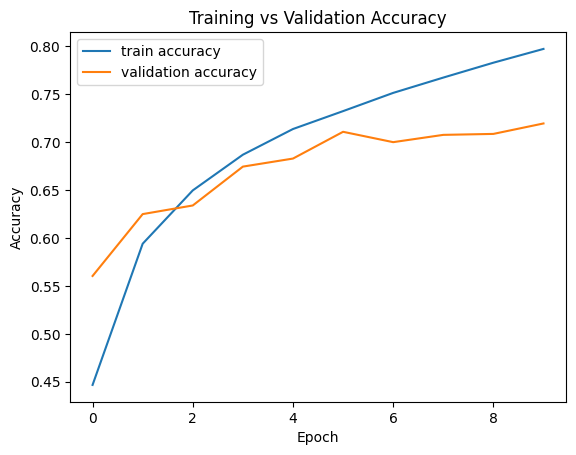

In [7]:
# Plot training vs validation accuracy

plt.plot(history.history['accuracy'], label='train accuracy')         # Training accuracy per epoch
plt.plot(history.history['val_accuracy'], label='validation accuracy') # Validation accuracy per epoch

plt.xlabel("Epoch")    # X-axis: training round number
plt.ylabel("Accuracy") # Y-axis: classification accuracy
plt.legend()           # Show the legend (labels for each line)

plt.title("Training vs Validation Accuracy")

plt.show()